<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#04. Pytorch Custom Datasets Video Notebook

we've used some datasets with pytorch before.

But how do you get your own data into pytorch?

one of the ways to do so is via: custom datasets.

##Domain libraries

Depending on what u are working on, vision, text, audio, recommendation, you will want to look into each of the pytorch domain libraies for existing loading functions and customizable data loading functions.


In [1]:
import torch
from torch import nn


In [2]:
torch.__version__

'2.6.0+cu124'

In [3]:
#setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
!nvidia-smi

Mon Apr 14 15:35:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. GET DATA

our dataset is a subset of the food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts wiht 3 classes of foofd and only 10% of the images (~75 training,25 testing)

why do this?

when starting out ML projects, its important to try things on a small scale and then increase the scale when necessary

The whole point is to speed up how fast u can experiment

In [5]:
import requests
import zipfile
from pathlib import Path

# setup path to data folder
data_path = Path("data/")
image_path =data_path / "pizza_steak_sushi"

#if the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory exists")
else:
  print(f"{image_path} doenot exist,creating one ...")
  image_path.mkdir(parents=True,exist_ok=True)

  #download pizza, steak and sushi data
  with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    requests=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading data..")
    f.write(requests.content)

  #unzip file
  with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("unzippind data...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi doenot exist,creating one ...
unzippind data...


## 2. Becoming one with the data(data exploration and data preparation)

In [6]:
import os
def walk_through_dir(dir_path):
  """walks thorgh dir_path returning its contents..."""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [7]:
walk_through_dir(image_path)

there are 2 directories and 0 images in 'data/pizza_steak_sushi'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
there are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
there are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
there are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
there are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
there are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
there are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'


In [8]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# 2.1 visualizing image

lets write some code too:
1. Get all of the inage paths.
2. Pick a random image path using pythons random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working wiht image ,lets open the image with pythons PIL.
5. we will then show the image and print metadata


data/pizza_steak_sushi/train/steak/1966300.jpg
steak
random image path:data/pizza_steak_sushi/train/steak/1966300.jpg
Image class:steak
Image height:512
Image width:512


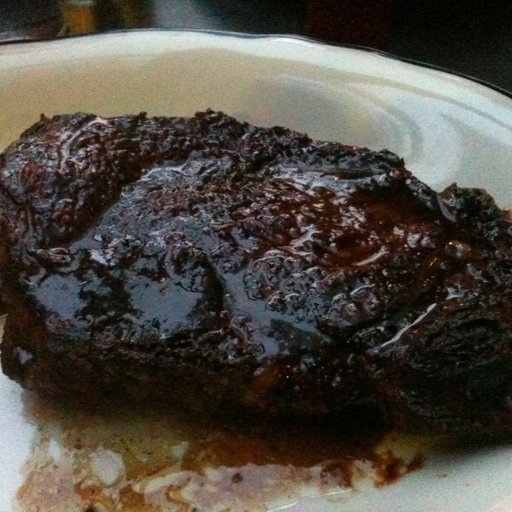

In [9]:
import random
from PIL import Image

# random.seed(42)

#1. Get all image paths
image_path_list=list(image_path.glob("*/*/*.jpg"))
# image_path_list

#2 pick a random image path

random_imag_path = random.choice(image_path_list)
print(random_imag_path)

#3 Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_imag_path.parent.stem
print(image_class)

#4 open image
img =Image.open(random_imag_path)

#5 print metadata
print(f"random image path:{random_imag_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width:{img.width}")
img

Text(0.5, 1.0, 'image clas :steak | image shape :(512, 512, 3) ')

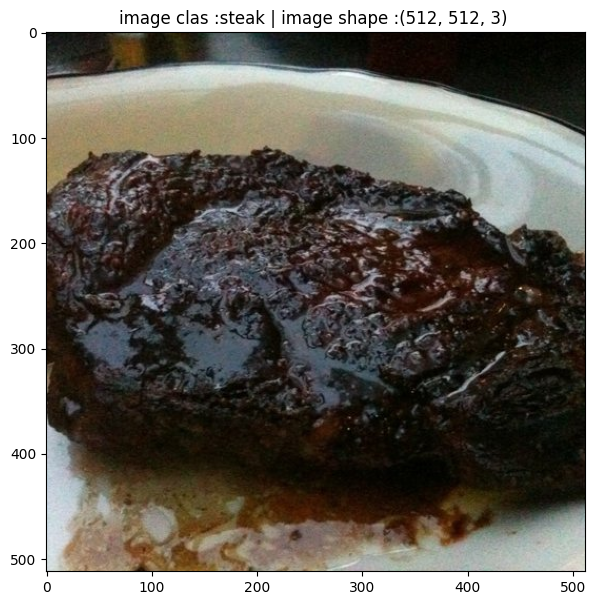

In [10]:
import matplotlib.pyplot as plt
import numpy as np
# trun image into array
imag_as_arr = np.asarray(img)
# imag_as_arr.shape


# plt.imshow(img)
plt.figure(figsize=(10,7))
plt.imshow(imag_as_arr)
plt.title(f"image clas :{image_class} | image shape :{imag_as_arr.shape} ")

## 3. Transforming data

Before we can use our image data with pytorch

1. Turn your target data into tensors (in our case, numerical representation of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.uti,s.data.Dataloader`, we will call these dataset and dataloader.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 3.1 tranforming data with torchvision.transform

transforms help u to get image ready to perofrom augmentation

In [ ]:
# write a transform for image
data_transform = transforms.Compose([
    # resize our images to 64*64
    transforms.Resize(size=(64,64)),
    #flip images randomly on horizontally
    transforms.RandomHorizontalFlip(p=0.5),
    #turn the image into torch tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).dtype

In [ ]:
def plot_tranformed_images(image_paths:list,transform,n=3,seed=None):
  """
  selects random image from a path of images and loads/ transform them  then plpots the orig vs tranformed image
  """
  if seed:
    random.seed(seed)
  random_image_path = random.sample(image_paths,k=n)
  for image_path in random_image_path:
    with Image.open(image_path) as f:
      fig,ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\n size:{f.size}")
      ax[0].axis("off")

      #transform and plot the image
      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed image:{transformed_image.shape}")

      fig.suptitle(f"class: {image_path.parent.stem}",fontsize=16)
plot_tranformed_images(image_path_list,data_transform,n=3, seed=None)